In [1]:
import numpy as np
import pandas as pd

import functions.io as fio
import functions.relations as rl
import functions.plot as plot

import warnings
warnings.filterwarnings("ignore")


# Load saved models and run the Empirical ETC

Set your desired RV uncertainty, the stellar teff, and its G magnitude.

Returned are:
- The estimated exposure time to achieve the desired RV uncertainty under nominal Keck Observatory conditions
- The value of "exp_meter_thresh" to put in the OB
- The estimated counts on the L1 file near 652nm (sum of all orderlets) from which you can estimate SNR via your own science requirements

In [2]:
fits_saved, equations_saved = fio.load_fit_results_h5("data/Feb2026_fits.h5")

desired_rv_err = 0.5
st_teff = 5750
gmag = 9.0
exptime, threshOB, spectrum_counts_g = rl.compute_exptime_from_rv_linear(desired_rv_err, st_teff, gmag, fits_saved, equations_saved)

print("Exptime: ", exptime)
print("OB exp_meter_thresh value: ", threshOB)
print("Estimated L1 Counts near 652nm: ", spectrum_counts_g)


Exptime:  1113
OB exp_meter_thresh value:  0.405
Estimated L1 Counts near 652nm:  296253


# Build the Models

Now that we've demonstrated the usefulness of the models, let's construct them from scratch. This requires only a csv containing data on the past observations with KPF. This can be obtained by a database query on Jump. See the /data/ directory for the exact query. 

In [3]:
data = fio.prepare_data('data/Feb2026.csv')


Relate the count rate to the stellar G magnitude. Using the 75th percentile tracks closer with average nominal conditions


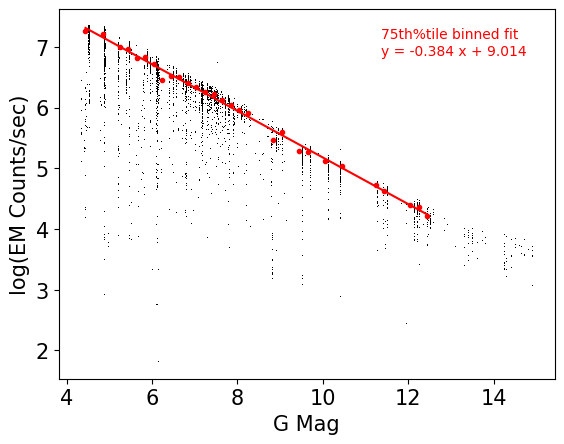

In [4]:
magEM_slope, magEM_intercept, x_fit, y_fit = rl.get_mag_to_EMcountrate_slope_intercept(data)
plot.gmag_to_EMcountrate(data, magEM_slope, magEM_intercept, x_fit, y_fit)

Relate the counts on the Exposure Meter to the counts on the L1 spectrum near 652nm

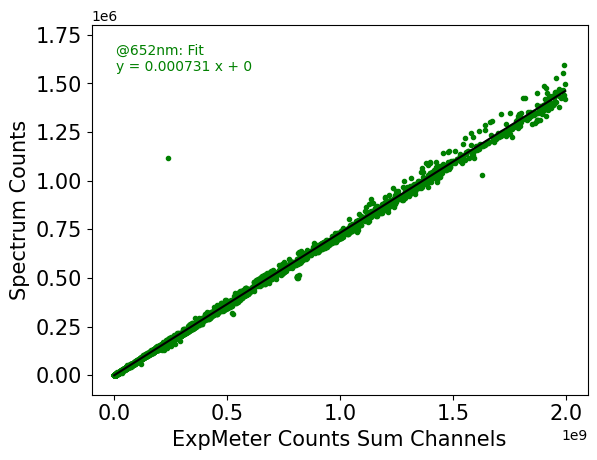

In [5]:
emc_scic_slope, emc_scic_intercept = rl.get_EMcounts_to_Scicounts_slope_intercept(data)
plot.EMcounts_to_Scicounts(data, emc_scic_slope, emc_scic_intercept)

Build a dictionary to store the slopes/intercepts of these two relationships.  This dictionary is one half of the information that powers the desired RV uncertainty estimation. 


In [6]:
equations = {}
equations['mag_to_EMcounts_slope'] = magEM_slope
equations['mag_to_EMcounts_intercept'] = magEM_intercept
equations['EMcounts_to_SCIcounts_slope'] = emc_scic_slope
equations['EMcounts_to_SCIcounts_intercept'] = emc_scic_intercept


Construct a grid of OB threshold values and G mags to build a map of estimated exposure times. The lines for each star are parallel in log-log space, with intercept differences of approx. 0.383 per G mag. You can use these equations to estimate exposure times between the magnitudes if you like. 


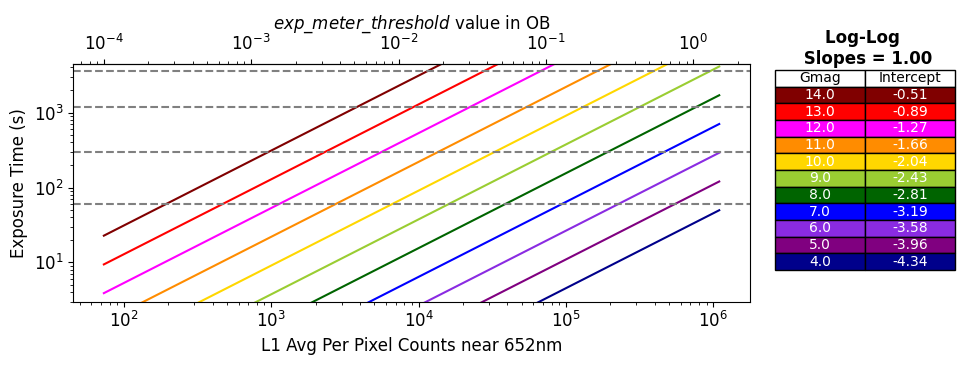

In [7]:
test_thresh = np.linspace(0.0001, 1.5, 8)
test_gmag = np.arange(4., 14.1, 1)
times, snrs, threshes, test_thresh = rl.build_grids(equations, test_thresh, test_gmag)
plot.exptime_per_counts_or_OBthresh(times, snrs, threshes, test_gmag, test_thresh)


Now fit the relationship between counts on L1 file and the estimated RV uncertainty. Note that this relationship is likely at least partially dependent on the DRP version. We bin the data to match the teff bins of the DRP's line list mask determination.


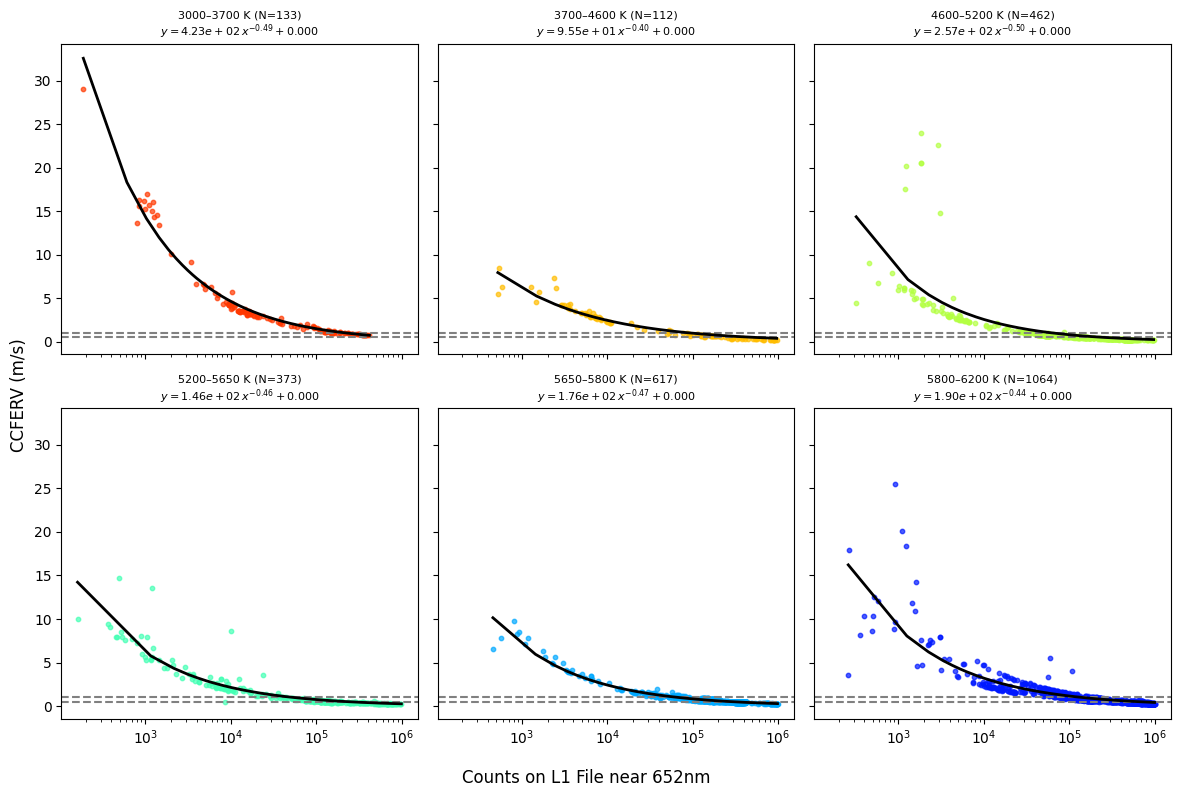

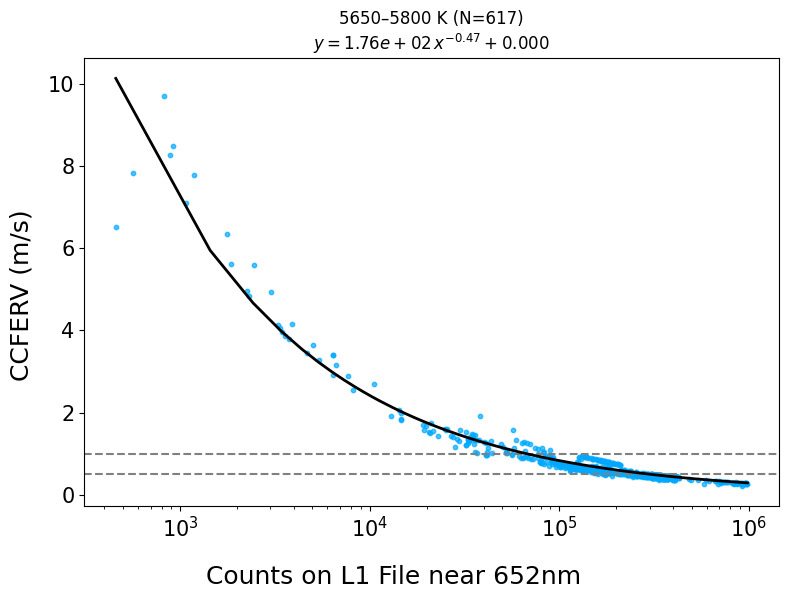

In [8]:
teff_bins = [3000, 3700, 4600, 5200, 5650, 5800, 6200]
fits = rl.fit_teff_bins(data, teff_bins, min_points=20)

plot.plot_indv_counts_to_err_fits(fits)
plot.plot_indv_counts_to_err_fits(fits, index=4)


This is the relationship (plotted in log-log space, but equations in linear) that defines the estimated RV uncertainty with the counts on the L1 file.

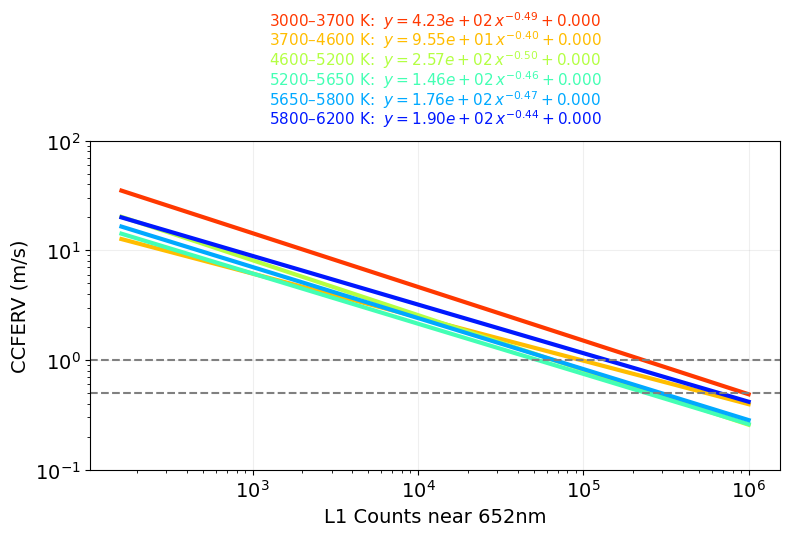

In [9]:
plot.plot_global_counts_to_err_fits(fits)